In [30]:
import gdsfactory as gf
import componentsLucas as comp
import numpy as np

In [31]:
gf.clear_cache()
gf.gpdk.PDK.activate()
c = gf.Component('TOP')

In [32]:
'''
gds name
'''

gdsname = 'MZI_50GHZ_2_stages_Lucas.gds'

'''
Circuit center

The circuit fits in a 850x590 μm box.
'''

x = 0 
y = 0

'''
Paperclip sprirals length (μm)
'''

length_193 = 193.597
length_890 = 890.327
length_1608 = 1608.635
length_3028 = 3028.174

'''
Grating couplers spacing (μm)
'''

gc_spacing = 127

## MZI 50 GHz ##

In [33]:
'''
Y Branchs positions
'''

x_Y1 = -230
y_Y1 = 220

x_Y2 = 0
y_Y2 = 0

x_Y3 = 0
y_Y3 = 0

In [34]:
Y1 = c << comp.yEbeam()
Y1.rotate(-90)
Y1.center = (x + x_Y1, y + y_Y1)

Y1_o1 = Y1['o1']
Y1_o2 = Y1['o2']
Y1_o3 = Y1['o3']

Pspiral1608_1 = c << comp.nanotoolsSpiralPaperclip(length_1608)
Pspiral1608_1.rotate(180)
Pspiral1608_1.center = (Y1.x - 140, Y1.y - 50)

route1 = gf.routing.route_single(
    c,
    Y1_o2,
    Pspiral1608_1['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Y1_o2.x, Pspiral1608_1.ports['o2'].y)],
)

DC13_1 = c << comp.dcEbeam_13()
DC13_1.rotate(90)
DC13_1.center = (Pspiral1608_1['o1'].x + 2.35 , Pspiral1608_1['o1'].y - 10.178 - 30.864)

route2 = gf.routing.route_single(
    c,
    Pspiral1608_1['o1'],
    DC13_1['o4'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)

route3 = gf.routing.route_single(
    c,
    Y1_o3,
    DC13_1.ports['o3'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Y1_o3.x, Y1_o3.y - 10), (Y1_o3.x + 20, Y1_o3.y - 10), (Y1_o3.x + 20, DC13_1.y), (Y1_o3.x + 10, DC13_1.y), (Y1_o3.x + 10, DC13_1.y + 50 + 10.157), (DC13_1['o3'].x, DC13_1.y + 50 + 10.157)]
)

In [35]:

print('Waveguide 1 length: %.3f μm.' %((route1.length + route2.length)/1000 + length_1608))
print('Waveguide 2 length: %.3f μm.' %(route3.length/1000))

Waveguide 1 length: 1661.568 μm.
Waveguide 2 length: 249.842 μm.


In [36]:
DC12_1 = c << comp.dcEbeam_12()
DC12_1.rotate(90)
DC12_1.center = (DC13_1.x, DC13_1.y - np.abs(Y1.y - DC13_1.y) - 0.003)

route4 = gf.routing.route_single(
    c,
    DC13_1['o1'],
    DC12_1['o3'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC13_1['o1'].x, DC13_1['o1'].y - 10), (DC13_1['o1'].x + 20, DC13_1['o1'].y - 10), (DC13_1['o1'].x + 20, DC12_1.y), (DC13_1['o1'].x + 10, DC12_1.y), (DC13_1['o1'].x + 10, DC12_1.y + 50 + 13.545 - 0.001), (DC12_1['o3'].x, DC12_1.y + 50 + 13.545 - 0.001)]
)

Pspiral3028_1 = c << comp.nanotoolsSpiralPaperclip(length_3028)
Pspiral3028_1.rotate(180)
Pspiral3028_1.center = (DC13_1.x - 145 - 0.028, DC13_1['o2'].y - 46)

route5 = gf.routing.route_single(
    c,
    DC13_1['o2'],
    Pspiral3028_1['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC13_1['o2'].x, DC13_1['o2'].y - 5)],
)

route6 = gf.routing.route_single(
    c, 
    Pspiral3028_1['o1'],
    DC12_1['o4'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral3028_1['o1'].x, Pspiral3028_1['o1'].y - 5), (DC12_1['o4'].x, Pspiral3028_1['o1'].y - 5)]
)

In [37]:
print('Waveguide 3 length: %.3f μm.' %((route5.length + route6.length)/1000 + length_3028))
print('Waveguide 4 length: %.3f μm.' %(route4.length/1000))

Waveguide 3 length: 3073.136 μm.
Waveguide 4 length: 250.001 μm.


In [38]:
DC50_1 = c << comp.dcEbeam_50()
DC50_1.rotate(90)
DC50_1.center = (DC12_1.x, DC12_1.y - np.abs(Y1.y - DC13_1.y) - 5.74)

route7 = gf.routing.route_single(
    c,
    DC12_1['o2'],
    DC50_1['o4'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC12_1['o2'].x, DC12_1['o2'].y - 10), (DC12_1['o2'].x - 20, DC12_1['o2'].y - 10), (DC12_1['o2'].x - 20, DC50_1.y), (DC12_1['o2'].x - 10, DC50_1.y), (DC12_1['o2'].x - 10, DC50_1.y + 50 + 13.702), (DC50_1['o4'].x, DC50_1.y + 50 + 13.702)]
)

Pspiral3028_2 = c << comp.nanotoolsSpiralPaperclip(length_3028)
Pspiral3028_2.rotate(0)
Pspiral3028_2.mirror_y()
Pspiral3028_2.center = (DC12_1.x + 145 + 0.028, DC12_1['o1'].y - 46)

route8 = gf.routing.route_single(
    c,
    DC12_1['o1'],
    Pspiral3028_2['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC12_1['o1'].x, DC12_1['o1'].y - 5)],
)

route9 = gf.routing.route_single(
    c, 
    Pspiral3028_2['o1'],
    DC50_1['o3'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral3028_2['o1'].x, Pspiral3028_2['o1'].y - 5), (DC50_1['o3'].x, Pspiral3028_2['o1'].y - 5)]
)

In [39]:
print('Waveguide 5 length: %.3f μm.' %(route7.length/1000))
print('Waveguide 6 length: %.3f μm.' %((route8.length + route9.length)/1000 + length_3028))

Waveguide 5 length: 250.000 μm.
Waveguide 6 length: 3072.819 μm.


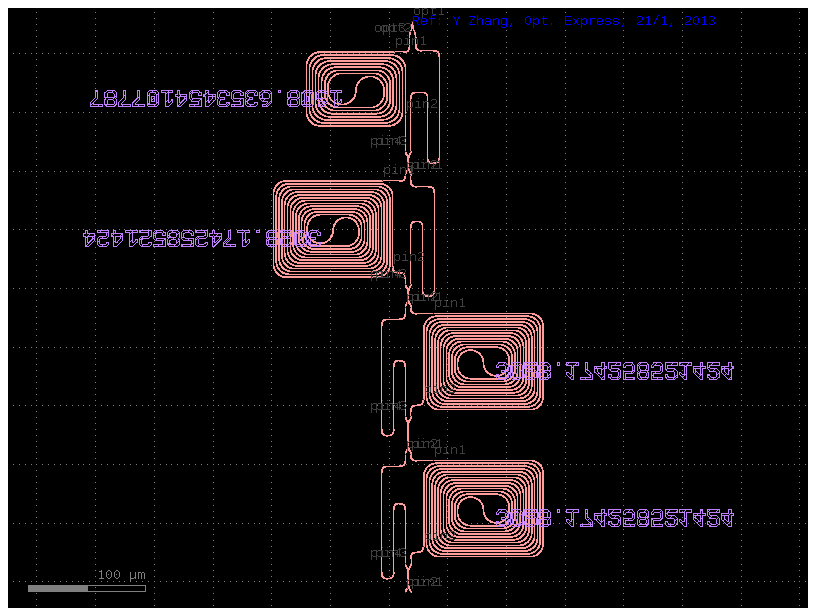

In [40]:
DC25_1 = c << comp.dcEbeam_25()
DC25_1.rotate(90)
DC25_1.center = (DC50_1.x, DC50_1.y - np.abs(Y1.y - DC13_1.y) - 8.57)

route10 = gf.routing.route_single(
    c,
    DC50_1['o2'],
    DC25_1['o4'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC50_1['o2'].x, DC50_1['o2'].y - 10), (DC50_1['o2'].x - 20, DC50_1['o2'].y - 10), (DC50_1['o2'].x - 20, DC25_1.y), (DC50_1['o2'].x - 10, DC25_1.y), (DC50_1['o2'].x - 10, DC25_1.y + 50 + 13.543), (DC25_1['o4'].x, DC25_1.y + 50 + 13.543)]
)

Pspiral3028_3 = c << comp.nanotoolsSpiralPaperclip(length_3028)
Pspiral3028_3.rotate(0)
Pspiral3028_3.mirror_y()
Pspiral3028_3.center = (DC50_1.x + 145 + 0.028, DC50_1['o1'].y - 46)

route11 = gf.routing.route_single(
    c,
    DC50_1['o1'],
    Pspiral3028_3['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC50_1['o1'].x, DC50_1['o1'].y - 5)],
)

route12 = gf.routing.route_single(
    c, 
    Pspiral3028_3['o1'],
    DC25_1['o3'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral3028_3['o1'].x, Pspiral3028_3['o1'].y - 5), (DC25_1['o3'].x, Pspiral3028_3['o1'].y - 5)]
)

c.write_gds(gdsname)
c.show()
c.plot()

In [41]:
print('Waveguide 7 length: %.3f μm.' %(route10.length/1000))
print('Waveguide 8 length: %.3f μm.' %((route11.length + route12.length)/1000 + length_3028))

Waveguide 7 length: 249.999 μm.
Waveguide 8 length: 3073.136 μm.


## MZIs 100 GHz ###

### MZI 100 GHz 1 ###

In [42]:
Y2 = c << comp.yEbeam()
Y2.rotate(90)
Y2.center = (DC25_1.x + 220, DC25_1.y)

Y2_o1 = Y2['o1']
Y2_o2 = Y2['o2']
Y2_o3 = Y2['o3']

route13 = gf.routing.route_single(
    c, 
    DC25_1['o1'],
    Y2_o1,
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC25_1['o1'].x, DC25_1['o1'].y - 10), (Y2_o1.x, DC25_1['o1'].y - 10)]
)

Pspiral890_1 = c << comp.nanotoolsSpiralPaperclip(length_890)
Pspiral890_1.rotate(0)
#Pspiral890_1.mirror_y()
Pspiral890_1.center = (Y2.x + 135.653, Y2.y + 50)

route14 = gf.routing.route_single(
    c, 
    Y2_o2,
    Pspiral890_1['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Y2_o2.x, Pspiral890_1['o2'].y)],
)

DC13_2 = c << comp.dcEbeam_13()
DC13_2.rotate(90)
DC13_2.center = (Pspiral890_1['o1'].x - 2.35, Pspiral890_1['o1'].y + 10.178 + 30.864)

route15 = gf.routing.route_single(
    c, 
    Pspiral890_1['o1'],
    DC13_2['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)

route16 = gf.routing.route_single(
    c, 
    Y2_o3,
    DC13_2['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints= [(Y2_o3.x, Y2_o3.y + 10), (Y2_o3.x - 20, Y2_o3.y + 10), (Y2_o3.x - 20, DC13_2.y), (Y2_o3.x - 10, DC13_2.y), (Y2_o3.x - 10, DC13_2.y - 50 - 12.205), (DC13_2['o2'].x, DC13_2.y - 50 - 12.205)]
)

In [43]:
print('Waveguide 9 length: %.3f μm.' %((route14.length + route15.length)/1000 + length_890))
print('Waveguide 10 length: %.3f μm.' %(route16.length/1000))

Waveguide 9 length: 955.863 μm.
Waveguide 10 length: 249.841 μm.


In [44]:
DC12_2 = c << comp.dcEbeam_12()
DC12_2.rotate(90)
DC12_2.center = (DC13_2.x, DC13_2.y + np.abs(Y1.y - DC13_1.y) - 11.011)

route17 = gf.routing.route_single(
    c,
    DC13_2['o4'],
    DC12_2['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC13_2['o4'].x, DC13_2['o4'].y + 10), (DC13_2['o4'].x - 20, DC13_2['o4'].y + 10), (DC13_2['o4'].x - 20, DC12_2.y), (DC13_2['o4'].x - 10, DC12_2.y), (DC13_2['o4'].x - 10, DC12_2.y - 50 - 19.051), (DC12_2['o2'].x, DC12_2.y - 50 - 19.051)]
)


Pspiral1608_2 = c << comp.nanotoolsSpiralPaperclip(length_1608)
Pspiral1608_2.rotate(0)
Pspiral1608_2.center = (DC13_2.x + 146.5, DC13_2['o3'].y + 46)


route18 = gf.routing.route_single(
    c,
    DC13_2['o3'],
    Pspiral1608_2['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC13_2['o3'].x, Pspiral1608_2['o2'].y)],
)


route19 = gf.routing.route_single(
    c, 
    Pspiral1608_2['o1'],
    DC12_2['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral1608_2['o1'].x, Pspiral1608_2['o1'].y + 5), (DC12_2['o1'].x, Pspiral1608_2['o1'].y + 5)]
)

In [45]:
print('Waveguide 11 length: %.3f μm.' %((route14.length + route15.length)/1000 + length_890))
print('Waveguide 12 length: %.3f μm.' %(route17.length/1000))


Waveguide 11 length: 955.863 μm.
Waveguide 12 length: 250.001 μm.


In [46]:
DC50_2 = c << comp.dcEbeam_50()
DC50_2.rotate(90)
DC50_2.center = (DC12_2.x, DC12_2.y + np.abs(Y1.y - DC13_1.y) - 5.274)


route20 = gf.routing.route_single(
    c,
    DC12_2['o3'],
    DC50_2['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC12_2['o3'].x, DC12_2['o3'].y + 10), (DC12_2['o3'].x + 20, DC12_2['o3'].y + 10), (DC12_2['o3'].x + 20, DC50_2.y), (DC12_2['o3'].x + 10, DC50_2.y), (DC12_2['o3'].x + 10, DC50_2.y - 50 - 19.209), (DC50_2['o1'].x, DC50_2.y - 50 - 19.209)]
)

Pspiral1608_3 = c << comp.nanotoolsSpiralPaperclip(length_1608)
Pspiral1608_3.rotate(180)
Pspiral1608_3.mirror_y()
Pspiral1608_3.center = (DC50_2.x - 146.5, DC50_2['o1'].y - 34.986)

route21 = gf.routing.route_single(
    c,
    DC12_2['o4'],
    Pspiral1608_3['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC12_2['o4'].x, Pspiral1608_3['o2'].y)],
)

route22 = gf.routing.route_single(
    c, 
    Pspiral1608_3['o1'],
    DC50_2['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral1608_3['o1'].x, Pspiral1608_3['o1'].y + 5), (DC50_2['o2'].x, Pspiral1608_3['o1'].y + 5)]
)

In [47]:
print('Waveguide 13 length: %.3f μm.' %(route20.length/1000))
print('Waveguide 14 length: %.3f μm.' %((route21.length + route22.length)/1000 + length_1608))

Waveguide 13 length: 250.000 μm.
Waveguide 14 length: 1661.410 μm.


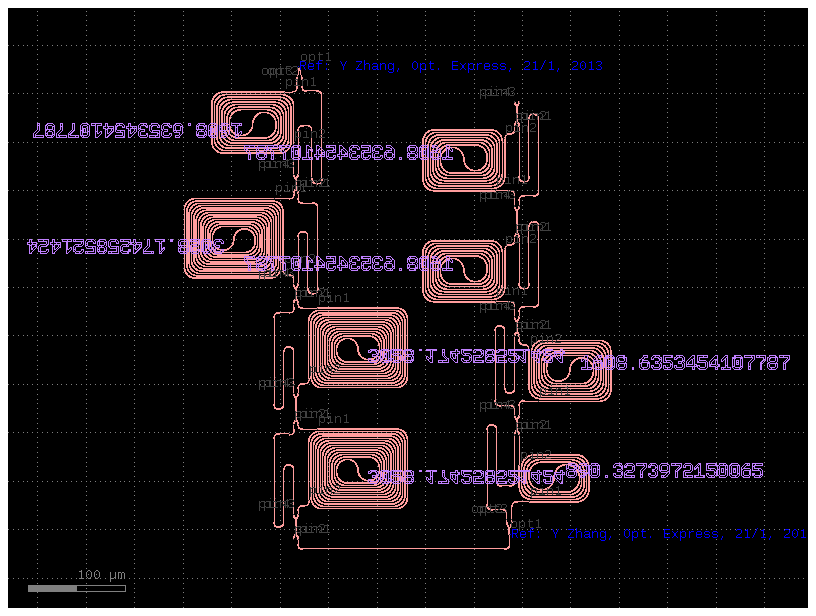

In [48]:
DC25_2 = c << comp.dcEbeam_25()
DC25_2.rotate(90)
DC25_2.center = (DC50_2.x, DC50_2.y + np.abs(Y1.y - DC13_1.y) - 2.444)


route23 = gf.routing.route_single(
    c,
    DC50_2['o3'],
    DC25_2['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC50_2['o3'].x, DC50_2['o3'].y + 10), (DC50_2['o3'].x + 20, DC50_2['o3'].y + 10), (DC50_2['o3'].x + 20, DC25_2.y), (DC50_2['o3'].x + 10, DC25_2.y), (DC50_2['o3'].x + 10, DC25_2.y - 50 - 19.051), (DC25_2['o1'].x, DC25_2.y - 50 - 19.051)]
)

Pspiral1608_4 = c << comp.nanotoolsSpiralPaperclip(length_1608)
Pspiral1608_4.rotate(180)
Pspiral1608_4.mirror_y()
Pspiral1608_4.center = (DC25_2.x - 146.5, DC25_2['o1'].y - 34.986)

route24 = gf.routing.route_single(
    c,
    DC50_2['o4'],
    Pspiral1608_4['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC50_2['o4'].x, Pspiral1608_4['o2'].y)],
)

route25 = gf.routing.route_single(
    c, 
    Pspiral1608_4['o1'],
    DC25_2['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral1608_4['o1'].x, Pspiral1608_4['o1'].y + 5), (DC25_2['o2'].x, Pspiral1608_4['o1'].y + 5)]
)

c.write_gds(gdsname)
c.show()
c.plot()

In [49]:
print('Waveguide 15 length: %.3f μm.' %(route23.length/1000))
print('Waveguide 16 length: %.3f μm.' %((route24.length + route25.length)/1000 + length_1608))

Waveguide 15 length: 250.001 μm.
Waveguide 16 length: 1661.727 μm.


### MZI 100 GHz 2 ###

In [50]:
Y3 = c << comp.yEbeam()
Y3.rotate(90)
Y3.center = (DC25_1.x + 400, DC25_1.y)

Y3_o1 = Y3['o1']
Y3_o2 = Y3['o2']
Y3_o3 = Y3['o3']

route26 = gf.routing.route_single(
    c, 
    DC25_1['o2'],
    Y3_o1,
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC25_1['o2'].x, DC25_1['o2'].y - 20), (Y3_o1.x, DC25_1['o2'].y - 20)]
)

Pspiral890_2 = c << comp.nanotoolsSpiralPaperclip(length_890)
Pspiral890_2.rotate(0)
#Pspiral890_1.mirror_y()
Pspiral890_2.center = (Y3.x + 135.653, Y3.y + 50)

route27 = gf.routing.route_single(
    c, 
    Y3_o2,
    Pspiral890_2['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Y3_o2.x, Pspiral890_2['o2'].y)],
)

DC13_3 = c << comp.dcEbeam_13()
DC13_3.rotate(90)
DC13_3.center = (Pspiral890_2['o1'].x - 2.35, Pspiral890_2['o1'].y + 10.020 + 30.864)

route28 = gf.routing.route_single(
    c, 
    Pspiral890_2['o1'],
    DC13_3['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)

route29 = gf.routing.route_single(
    c, 
    Y3_o3,
    DC13_3['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints= [(Y3_o3.x, Y3_o3.y + 10), (Y3_o3.x - 20, Y3_o3.y + 10), (Y3_o3.x - 20, DC13_3.y), (Y3_o3.x - 10, DC13_3.y), (Y3_o3.x - 10, DC13_3.y - 50 - 12.284), (DC13_3['o2'].x, DC13_3.y - 50 - 12.284)]
)

In [51]:
print('Waveguide 17 length: %.3f μm.' %((route27.length + route28.length)/1000 + length_890))
print('Waveguide 18 length: %.3f μm.' %(route29.length/1000))

Waveguide 17 length: 955.705 μm.
Waveguide 18 length: 249.841 μm.


In [52]:
DC12_3 = c << comp.dcEbeam_12()
DC12_3.rotate(90)
DC12_3.center = (DC13_3.x, DC13_3.y + np.abs(Y1.y - DC13_1.y) - 11.328)

route30 = gf.routing.route_single(
    c,
    DC13_3['o4'],
    DC12_3['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC13_3['o4'].x, DC13_3['o4'].y + 10), (DC13_3['o4'].x - 20, DC13_3['o4'].y + 10), (DC13_3['o4'].x - 20, DC12_3.y), (DC13_3['o4'].x - 10, DC12_3.y), (DC13_3['o4'].x - 10, DC12_3.y - 50 - 19.209), (DC12_3['o2'].x, DC12_3.y - 50 - 19.209)]
)


Pspiral1608_5 = c << comp.nanotoolsSpiralPaperclip(length_1608)
Pspiral1608_5.rotate(0)
Pspiral1608_5.center = (DC13_3.x + 146.5, DC13_3['o3'].y + 46)


route31 = gf.routing.route_single(
    c,
    DC13_3['o3'],
    Pspiral1608_5['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC13_3['o3'].x, Pspiral1608_5['o2'].y)],
)


route32 = gf.routing.route_single(
    c, 
    Pspiral1608_5['o1'],
    DC12_3['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral1608_5['o1'].x, Pspiral1608_5['o1'].y + 5), (DC12_3['o1'].x, Pspiral1608_5['o1'].y + 5)]
)


In [53]:
print('Waveguide 19 length: %.3f μm.' %((route31.length + route32.length)/1000 + length_1608))
print('Waveguide 20 length: %.3f μm.' %(route30.length/1000))

Waveguide 19 length: 1661.410 μm.
Waveguide 20 length: 250.000 μm.


In [54]:
DC50_3 = c << comp.dcEbeam_50()
DC50_3.rotate(90)
DC50_3.center = (DC12_3.x, DC12_3.y + np.abs(Y1.y - DC13_1.y) - 5.591)


route33= gf.routing.route_single(
    c,
    DC12_3['o3'],
    DC50_3['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC12_3['o3'].x, DC12_3['o3'].y + 10), (DC12_3['o3'].x + 20, DC12_3['o3'].y + 10), (DC12_3['o3'].x + 20, DC50_3.y), (DC12_3['o3'].x + 10, DC50_3.y), (DC12_3['o3'].x + 10, DC50_3.y - 50 - 19.368), (DC50_3['o1'].x, DC50_3.y - 50 - 19.368)]
)

Pspiral1608_6 = c << comp.nanotoolsSpiralPaperclip(length_1608)
Pspiral1608_6.rotate(180)
Pspiral1608_6.mirror_y()
Pspiral1608_6.center = (DC50_3.x - 146.5, DC50_3['o1'].y - 34.986)

route34 = gf.routing.route_single(
    c,
    DC12_3['o4'],
    Pspiral1608_6['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC12_3['o4'].x, Pspiral1608_6['o2'].y)],
)

route35 = gf.routing.route_single(
    c, 
    Pspiral1608_6['o1'],
    DC50_3['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral1608_6['o1'].x, Pspiral1608_6['o1'].y + 5), (DC50_3['o2'].x, Pspiral1608_6['o1'].y + 5)]
)

In [55]:
print('Waveguide 21 length: %.3f μm.' %(route33.length/1000))
print('Waveguide 22 length: %.3f μm.' %((route34.length + route35.length)/1000 + length_1608))

Waveguide 21 length: 250.001 μm.
Waveguide 22 length: 1661.093 μm.


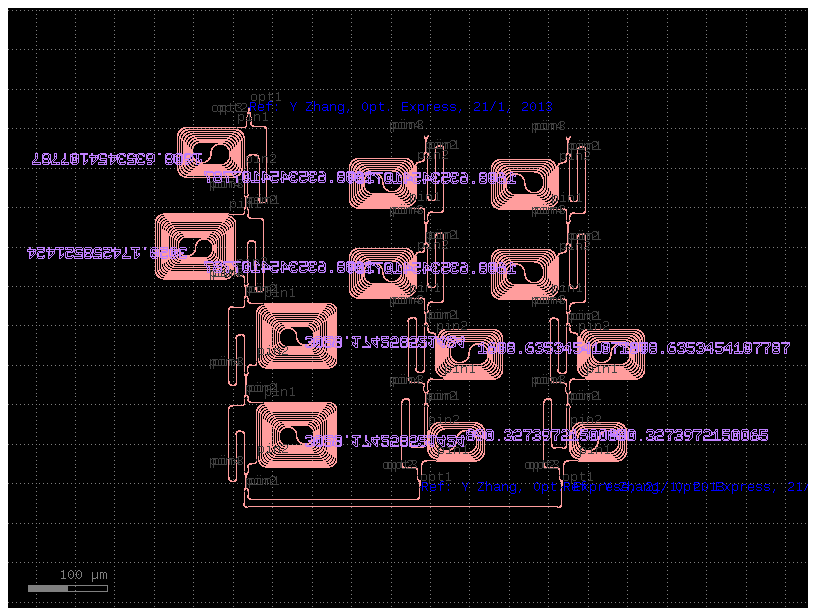

In [56]:
DC25_3 = c << comp.dcEbeam_25()
DC25_3.rotate(90)
DC25_3.center = (DC50_3.x, DC50_3.y + np.abs(Y1.y - DC13_1.y) - 2.761)


route38 = gf.routing.route_single(
    c,
    DC50_3['o3'],
    DC25_3['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC50_3['o3'].x, DC50_3['o3'].y + 10), (DC50_3['o3'].x + 20, DC50_3['o3'].y + 10), (DC50_3['o3'].x + 20, DC25_3.y), (DC50_3['o3'].x + 10, DC25_3.y), (DC50_3['o3'].x + 10, DC25_3.y - 50 - 19.209), (DC25_3['o1'].x, DC25_3.y - 50 - 19.209)]
)

Pspiral1608_7 = c << comp.nanotoolsSpiralPaperclip(length_1608)
Pspiral1608_7.rotate(180)
Pspiral1608_7.mirror_y()
Pspiral1608_7.center = (DC25_3.x - 146.5, DC25_3['o1'].y - 34.986)

route39 = gf.routing.route_single(
    c,
    DC50_3['o4'],
    Pspiral1608_7['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC50_3['o4'].x, Pspiral1608_7['o2'].y)],
)

route40 = gf.routing.route_single(
    c, 
    Pspiral1608_7['o1'],
    DC25_3['o2'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(Pspiral1608_7['o1'].x, Pspiral1608_7['o1'].y + 5), (DC25_3['o2'].x, Pspiral1608_7['o1'].y + 5)]
)

c.write_gds(gdsname)
c.show()
c.plot()

In [57]:
print('Waveguide 23 length: %.3f μm.' %(route38.length/1000))
print('Waveguide 24 length: %.3f μm.' %((route39.length + route40.length)/1000 + length_1608))

Waveguide 23 length: 250.000 μm.
Waveguide 24 length: 1661.410 μm.


## Adding the Grating Couplers ##

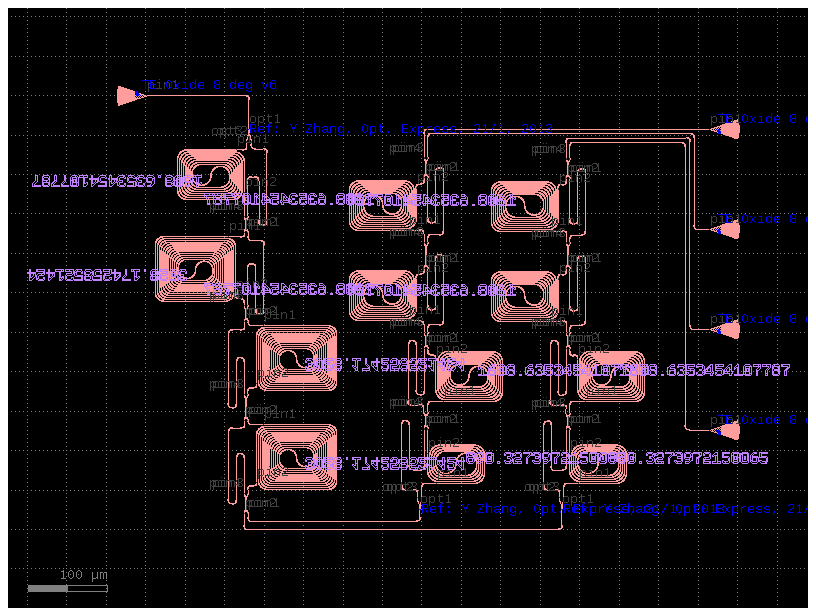

In [58]:
gcTE_in = c << comp.nanotools_gcTE()
gcTE_in.center = (Y1.x - 150, Y1.y + 50)

route_in = gf.routing.route_single(
    c, 
    gcTE_in['o1'],
    Y1_o1,
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)

gcTE_out1 = c << comp.nanotools_gcTE()
gcTE_out2 = c << comp.nanotools_gcTE()
gcTE_out3 = c << comp.nanotools_gcTE()
gcTE_out4 = c << comp.nanotools_gcTE()

gcTE_out1.rotate(180)
gcTE_out1.center = (DC25_3.x + 200, DC25_3.y + 50 - 0*gc_spacing)

gcTE_out2.rotate(180)
gcTE_out2.center = (DC25_3.x + 200, DC25_3.y + 50 - 1*gc_spacing)

gcTE_out3.rotate(180)
gcTE_out3.center = (DC25_3.x + 200, DC25_3.y + 50 - 2*gc_spacing)

gcTE_out4.rotate(180)
gcTE_out4.center = (DC25_3.x + 200, DC25_3.y + 50 - 3*gc_spacing)

route_out1 = gf.routing.route_single(
    c,
    DC25_2['o4'],
    gcTE_out1['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
)

route_out2 = gf.routing.route_single(
    c,
    DC25_2['o3'],
    gcTE_out2['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC25_2['o3'].x, gcTE_out1['o1'].y - 5.5), (gcTE_out2['o1'].x - 20, gcTE_out1['o1'].y - 5.5), (gcTE_out2['o1'].x - 20, gcTE_out2['o1'].y)]
)

route_out3 = gf.routing.route_single(
    c,
    DC25_3['o4'],
    gcTE_out3['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC25_3['o4'].x, gcTE_out1['o1'].y - 11), (gcTE_out3['o1'].x - 25.5, gcTE_out1['o1'].y - 11), (gcTE_out3['o1'].x - 25.5, gcTE_out3['o1'].y)]
)

route_out4 = gf.routing.route_single(
    c,
    DC25_3['o3'],
    gcTE_out4['o1'],
    radius=5,
    cross_section='strip',
    start_straight_length=10,
    waypoints=[(DC25_3['o3'].x, gcTE_out1['o1'].y - 16.5), (gcTE_out3['o1'].x - 31, gcTE_out1['o1'].y - 16.5), (gcTE_out3['o1'].x - 31, gcTE_out4['o1'].y)]
)

c.move((-c.xmin, -c.ymin))
c.write_gds(gdsname)
c.show()
c.plot()